In [64]:
import pandas as pd, numpy as np
from scipy.signal import find_peaks

# 读取 ECG csv
data = pd.read_csv('ecg_data-1110.csv')

# ⚙️ 自适应阈值：取信号90百分位
fs = 50
height_thr = np.percentile(data["ecg"], 90)
min_dist = int(0.4 * fs)  # 0.4秒间隔

# 心率计算
peaks, _ = find_peaks(data['ecg'], height=height_thr, distance=min_dist)
timestamps = data['time']
rr = np.diff(timestamps[peaks])
hr = 60 / rr

# 打个包
class ECGData(object):
    def __init__(self, data):
        self.peaks, _ = find_peaks(data['ecg'], height=height_thr, distance=min_dist)
        self.rr = np.diff(data['time'].loc[self.peaks])
        self.hr = 60 / self.rr

ecg = ECGData(data)
ecg.hr[-10:]


array([77.60298055, 75.54886033, 73.69283758, 75.64662445, 75.64382768,
       77.50296189, 79.76795307, 77.60243016, 79.61129827, 77.69008829])

## R 峰检测 Plot

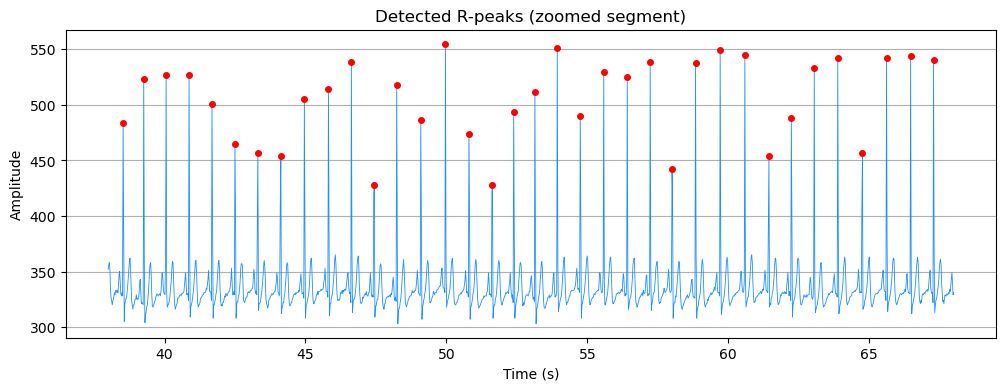

In [65]:
import matplotlib.pyplot as plt
data["is_peak"] = 0
data.loc[peaks, "is_peak"] = 1

start = np.random.randint(0, 240)
end = start + 30
mask = (data["time"] >= start) & (data["time"] <= end)

# 🎨 绘制滤波波形 + 红点标注
plt.figure(figsize=(12,4))
plt.plot(data["time"][mask], data["ecg"][mask], lw=0.6, color='dodgerblue')
plt.plot(data["time"][mask][data["is_peak"][mask]==1], data["ecg"][mask][data["is_peak"][mask]==1],
         "ro", ms=4)
plt.title("Detected R-peaks (zoomed segment)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True, axis='y')

143